In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # Hide sklearn feature name warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Lasso
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, BayesianRidge
import statsmodels.formula.api as sm
import matplotlib.pylab as plt
import pandas as pd
import numpy as np

import seaborn as sns
import dmba
from dmba import regressionSummary, exhaustive_search
from dmba import backward_elimination, forward_selection, stepwise_selection
from dmba import adjusted_r2_score, AIC_score, BIC_score


In [3]:
df = pd.read_csv('E:/MMAI5000_group_14_project/MMAI5000_group_14_project/Data-ATP-W119-PEW.csv')
print(df.head())
df.columns = [col[:-5] + '_W119' if col.lower().endswith('_w119') else col for col in df.columns]



     QKEY INTERVIEW_START_W119   INTERVIEW_END_W119  DEVICE_TYPE_W119  \
0  100314  12/13/2022 23:12:27  12/13/2022 23:23:59                 2   
1  100363  12/13/2022 19:50:59  12/13/2022 20:05:29                 2   
2  100598  12/14/2022 16:30:21  12/14/2022 16:47:21                 1   
3  100637  12/14/2022 08:22:09  12/14/2022 08:33:45                 1   
4  100803  12/15/2022 09:05:46  12/15/2022 09:22:29                 1   

   LANG_W119  FORM_W119  DESRISK_COMF_W119  DESRISK_CREAT_W119  \
0          1          1                  4                   3   
1          1          2                  3                   3   
2          1          1                  4                   4   
3          1          2                  2                   1   
4          1          2                  3                   3   

   DESRISK_NTECH_W119  RISK2_W119  ...  F_PARTYLN_FINAL  F_PARTYSUM_FINAL  \
0                   4           2  ...                                  1   
1         

C:\Users\User\AppData\Local\Temp\ipykernel_148928\673998768.py:1: DtypeWarning: Columns (154) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('E:/MMAI5000_group_14_project/MMAI5000_group_14_project/Data-ATP-W119-PEW.csv')


In [4]:
def plot_vars(df, max_cat_unique=20, bins=20, cols=5, figsize=(20, 4)):
    """
    Display a bar or histogram of all variables in a DataFrame on the same canvas.


    ----
    df : pandas.DataFrame
    max_cat_unique : int, if the number of uniques is less than or equal to this value, draw bars according to the categorical variable
    bins : int, the number of bins for the histogram
    cols : int, the number of sub-figures displayed per row
    figsize : tuple, the canvas size of each row of sub-figures
    """
    n = len(df.columns)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0], figsize[1]*rows))
    axes = axes.flatten()

    for i, col in enumerate(df.columns):
        ax = axes[i]
        if pd.api.types.is_numeric_dtype(df[col]):
            sns.histplot(df[col].dropna(), bins=bins, kde=False, ax=ax)
            ax.set_title(f'Hist of {col}')
            ax.set_xlabel(col)
            ax.set_ylabel('Count')
        else:
            n_unique = df[col].nunique(dropna=True)
            if n_unique <= max_cat_unique:
                sns.countplot(x=col, data=df, ax=ax)
                ax.set_title(f'Bar of {col}')
                ax.set_xlabel(col)
                ax.set_ylabel('Count')
                ax.tick_params(axis='x', rotation=30)
            else:
                ax.set_visible(False)  
                print(f"{col} 变量unique值太多（{n_unique}），跳过")
  
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [5]:
# Extract the specified variables
variables_to_extract = [
    'DESRISK_COMF_W119', 'DESRISK_CREAT_W119', 'DESRISK_NTECH_W119', 'RISK2_W119',
    'AI_HEARD_W119', 'CNCEXC_W119', 'USEAI_W119',
    'AIKNOW1_W119', 'AIKNOW2_W119', 'AIKNOW3_W119', 'AIKNOW5_W119', 'AIKNOW6_W119', 'AIKNOW7_W119',
    'AIKNOW1_CORRECT_W119', 'AIKNOW2_CORRECT_W119', 'AIKNOW3_CORRECT_W119', 
    'AIKNOW5_CORRECT_W119', 'AIKNOW6_CORRECT_W119', 'AIKNOW7_CORRECT_W119', 'AIKNOW_INDEX_W119',
    'AIHCCOMF_W119', 'AIHCTRT1_W119', 'AIHCTRT2_W119', 'MEDBIAS_W119',
    'AIHCCHG_QUAL_W119', 'AIHCCHG_MIST_W119', 'AIHCCHG_REL_W119', 'AIHCCHG_RACETHN_W119', 'AIHCCHG_SECUR_W119',
    'HCMEDBIAS_W119', 'EMPLSIT_W119', 'JOBAPPYR_W119', 'INDUSTRYCOMBO_W119',
    'AIWRK2_a_W119', 'AIWRK2_b_W119', 'AIWRK2_c_W119',
    'AIWRK3_a_W119', 'AIWRK3_b_W119', 'AIWRK3_c_W119',
    'AIWRKH1_W119', 'AIWRKH2_a_W119', 'AIWRKH2_b_W119',
    'AIWRKH3_a_W119', 'AIWRKH3_b_W119', 'AIWRKH3_c_W119', 'AIWRKH3_d_W119', 'AIWRKH4_W119',
    'AIWRKM1_W119', 'AIWRKM2_a_W119', 'AIWRKM2_b_W119', 'AIWRKM2_c_W119', 'AIWRKM2_d_W119',
    'AIWRKM2_e_W119', 'AIWRKM2_f_W119', 'AIWRKM3_a_W119', 'AIWRKM3_b_W119', 'AIWRKM3_c_W119',
    'AIWRKM3_d_W119', 'AIWRKM3_e_W119', 'AIWRKM3_f_W119', 'AIWRKM4_a_W119', 'AIWRKM4_b_W119',
    'F_AGECAT', 'F_GENDER', 'F_EDUCCAT', 'F_EDUCCAT2', 'F_RACECMB', 'F_RACETHNMOD',
    'F_CITIZEN', 'F_BIRTHPLACE', 'F_HISP', 'F_HISP_ORIGIN', 'F_CREGION', 'F_CDIVISION',
    'F_METRO', 'F_REG', 'F_INC_SDT1', 'F_INC_TIER2', 'F_MARITAL', 'F_RELIG',
    'F_RELIGCAT1', 'F_ATTEND', 'F_PARTY_FINAL', 'F_PARTYLN_FINAL', 'F_PARTYSUM_FINAL',
    'F_PARTYSUMIDEO_FINAL', 'F_IDEO'
]

# Check which variables exist in the dataset
available_vars = [var for var in variables_to_extract if var in df.columns]
missing_vars = [var for var in variables_to_extract if var not in df.columns]

print(f"Available variables: {len(available_vars)}")
print(f"Missing variables: {len(missing_vars)}")

if missing_vars:
    print(f"\nMissing variables: {missing_vars}")

# Extract the available variables
df_selected = df[available_vars].copy()

print(f"\nDataset shape after extraction: {df_selected.shape}")
print(f"Selected variables: {list(df_selected.columns)}")

# Display basic info about the extracted dataset
print(f"\nBasic info:")
print(df_selected.info())

Available variables: 87
Missing variables: 0

Dataset shape after extraction: (11004, 87)
Selected variables: ['DESRISK_COMF_W119', 'DESRISK_CREAT_W119', 'DESRISK_NTECH_W119', 'RISK2_W119', 'AI_HEARD_W119', 'CNCEXC_W119', 'USEAI_W119', 'AIKNOW1_W119', 'AIKNOW2_W119', 'AIKNOW3_W119', 'AIKNOW5_W119', 'AIKNOW6_W119', 'AIKNOW7_W119', 'AIKNOW1_CORRECT_W119', 'AIKNOW2_CORRECT_W119', 'AIKNOW3_CORRECT_W119', 'AIKNOW5_CORRECT_W119', 'AIKNOW6_CORRECT_W119', 'AIKNOW7_CORRECT_W119', 'AIKNOW_INDEX_W119', 'AIHCCOMF_W119', 'AIHCTRT1_W119', 'AIHCTRT2_W119', 'MEDBIAS_W119', 'AIHCCHG_QUAL_W119', 'AIHCCHG_MIST_W119', 'AIHCCHG_REL_W119', 'AIHCCHG_RACETHN_W119', 'AIHCCHG_SECUR_W119', 'HCMEDBIAS_W119', 'EMPLSIT_W119', 'JOBAPPYR_W119', 'INDUSTRYCOMBO_W119', 'AIWRK2_a_W119', 'AIWRK2_b_W119', 'AIWRK2_c_W119', 'AIWRK3_a_W119', 'AIWRK3_b_W119', 'AIWRK3_c_W119', 'AIWRKH1_W119', 'AIWRKH2_a_W119', 'AIWRKH2_b_W119', 'AIWRKH3_a_W119', 'AIWRKH3_b_W119', 'AIWRKH3_c_W119', 'AIWRKH3_d_W119', 'AIWRKH4_W119', 'AIWRKM1_W119

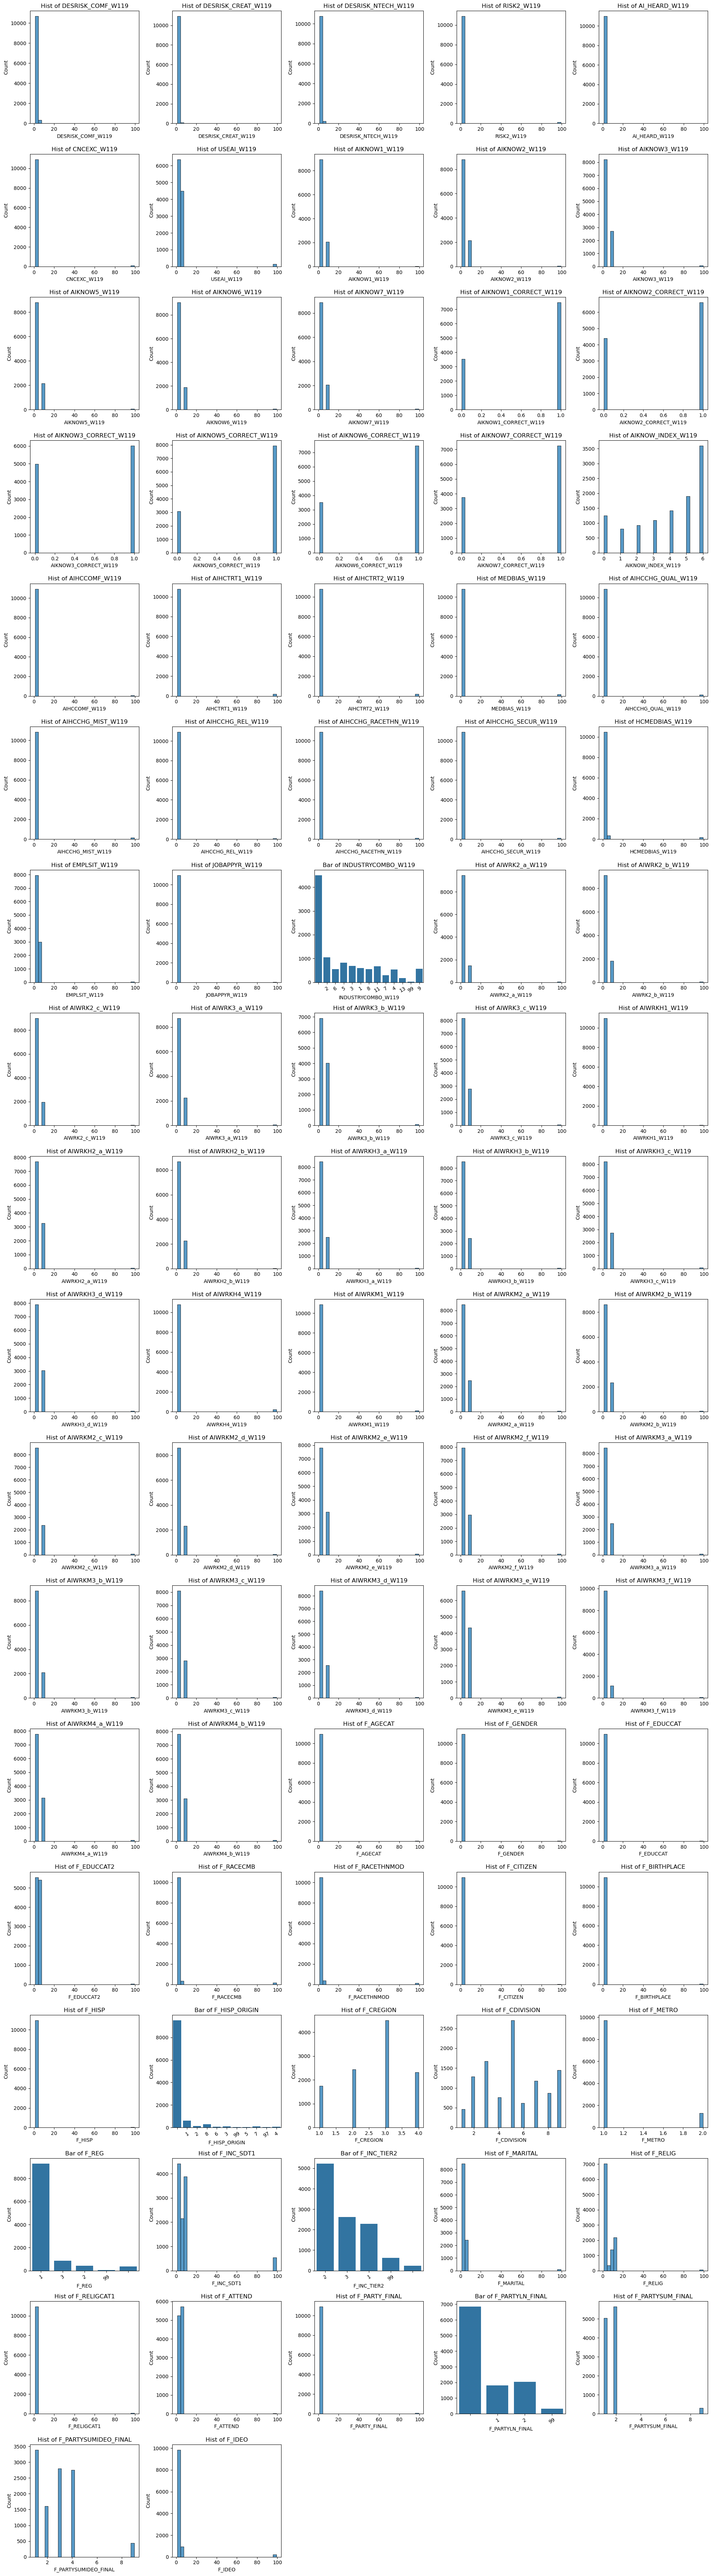

In [6]:
# View the distribution of all variables
import matplotlib.pyplot as plt
plot_vars(df_selected, max_cat_unique=20, bins=30, cols=5, figsize=(20, 4))


In [7]:
# Export descriptive statistics of numeric variables to CSV
num_cols = df_selected.select_dtypes(include=['number']).columns
num_stats = df_selected[num_cols].describe().transpose()
# num_stats.to_csv('numerical_variable_distribution.csv', index=True)
print("Numerical variable distribution saved to 'numerical_variable_distribution.csv'.")

# Export frequency statistics of categorical variables to CSV
cat_cols = df_selected.select_dtypes(include=['object', 'category']).columns
cat_stats_list = []
for col in cat_cols:
    value_counts = df_selected[col].value_counts(dropna=False)
    temp_df = value_counts.reset_index()
    temp_df.columns = ['value', 'count']
    temp_df['variable'] = col
    cat_stats_list.append(temp_df)
cat_stats_df = pd.concat(cat_stats_list, ignore_index=True)[['variable', 'value', 'count']]
# cat_stats_df.to_csv('categorical_variable_distribution.csv', index=False)
print("Categorical variable distribution saved to 'categorical_variable_distribution.csv'.")

Numerical variable distribution saved to 'numerical_variable_distribution.csv'.
Categorical variable distribution saved to 'categorical_variable_distribution.csv'.


Missing values after cleaning:
F_HISP_ORIGIN         9594
F_PARTYLN_FINAL       7157
INDUSTRYCOMBO_W119    4525
F_INC_TIER2            863
F_INC_SDT1             542
                      ... 
F_CITIZEN               13
DESRISK_NTECH_W119       8
AI_HEARD_W119            8
DESRISK_COMF_W119        7
DESRISK_CREAT_W119       6
Length: 75, dtype: int64

Missing value percentages:
F_HISP_ORIGIN         87.186478
F_PARTYLN_FINAL       65.039985
INDUSTRYCOMBO_W119    41.121410
F_INC_TIER2            7.842603
F_INC_SDT1             4.925482
                        ...    
F_CITIZEN              0.118139
AI_HEARD_W119          0.072701
DESRISK_NTECH_W119     0.072701
DESRISK_COMF_W119      0.063613
DESRISK_CREAT_W119     0.054526
Length: 75, dtype: float64

Dataset info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11004 entries, 0 to 11003
Data columns (total 87 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  

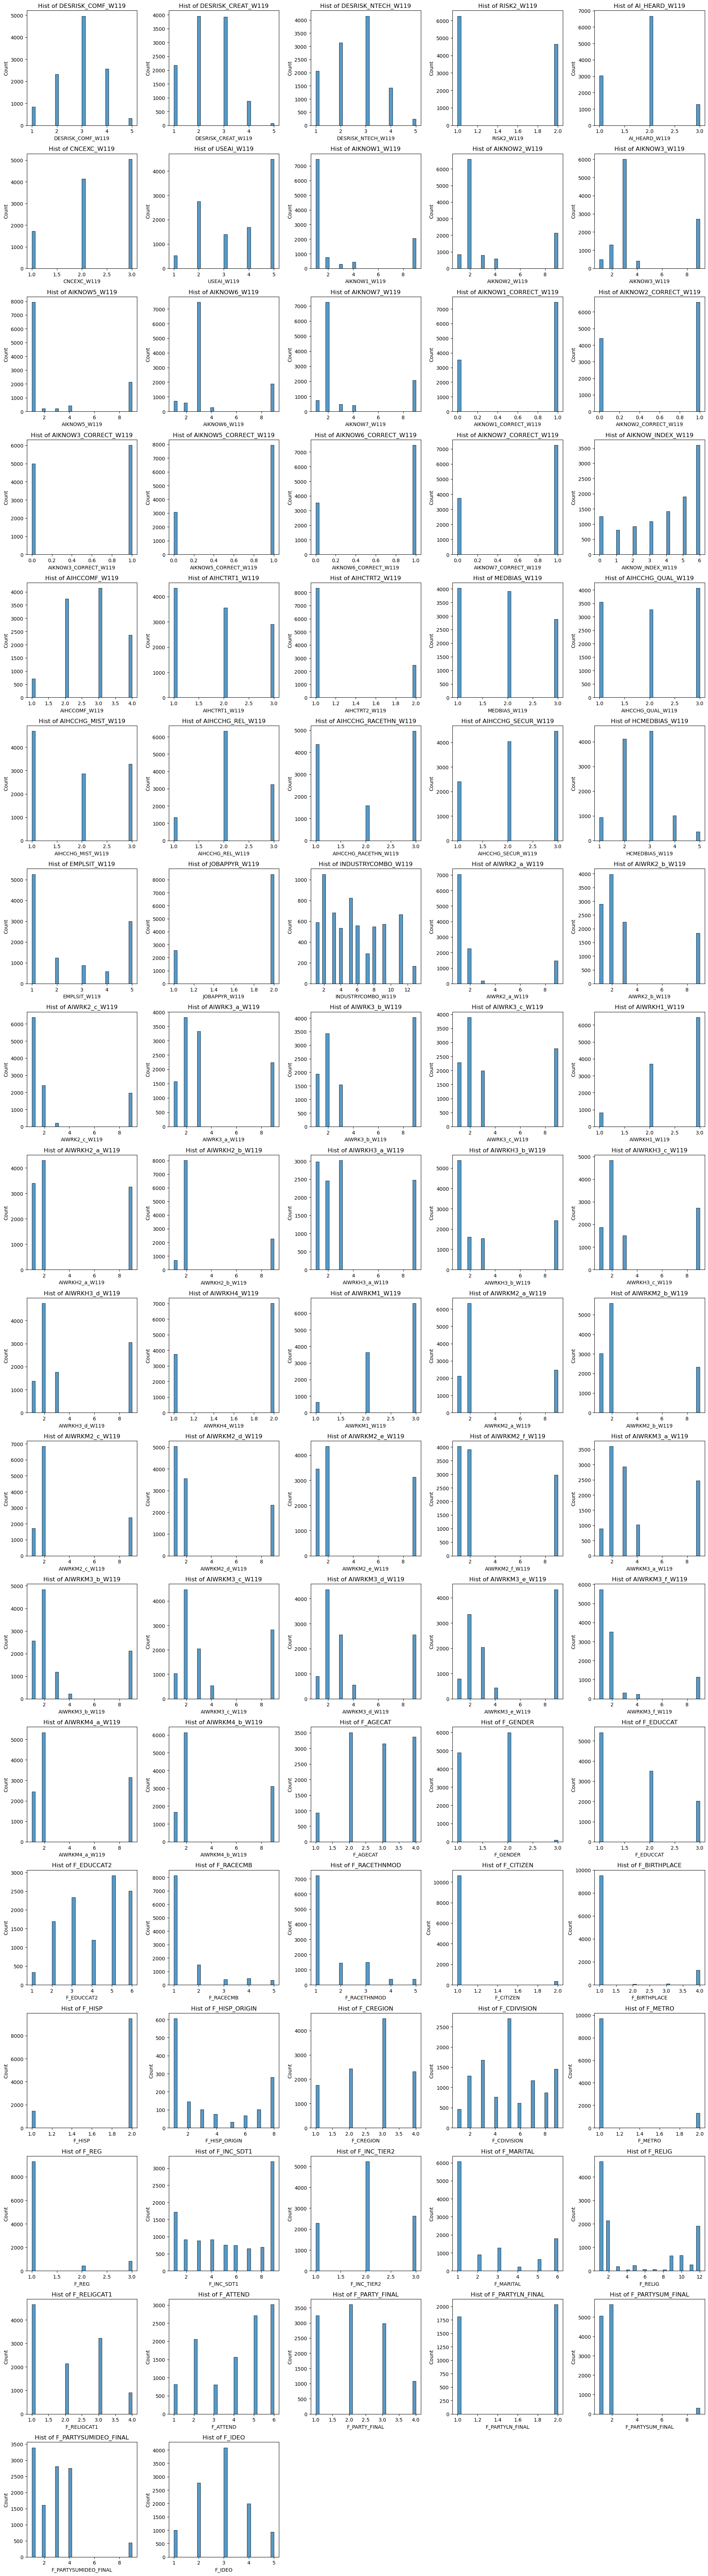

Original data shape: (11004, 87)
Cleaned data shape: (11004, 87)
Total missing values removed: 6376


In [8]:
# Dealing with missing value encoding

df_cleaned = df_selected.copy()
for col in df_cleaned.columns:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# Define the value that needs to be replaced with NaN
missing_codes = [97, 98, 99]

for col in df_cleaned.columns:
    df_cleaned[col] = df_cleaned[col].replace(missing_codes, np.nan)


print("Missing values after cleaning:")
missing_summary = df_cleaned.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
print(missing_summary)


missing_percentage = (df_cleaned.isnull().sum() / len(df_cleaned) * 100).sort_values(ascending=False)
missing_percentage = missing_percentage[missing_percentage > 0]
print(f"\nMissing value percentages:")
print(missing_percentage)


print(f"\nDataset info after cleaning:")
print(df_cleaned.info())

plot_vars(df_cleaned, max_cat_unique=20, bins=30, cols=5, figsize=(20, 4))

print(f"Original data shape: {df_selected.shape}")
print(f"Cleaned data shape: {df_cleaned.shape}")
print(f"Total missing values removed: {(df_selected == 99).sum().sum() + (df_selected == 98).sum().sum() + (df_selected == 97).sum().sum()}")

Likert scale variables have been recoded to ordinal numeric values.

Recoding summary:
- Attitude variables (reversed): ['DESRISK_COMF_W119', 'DESRISK_CREAT_W119', 'DESRISK_NTECH_W119', 'AIHCCOMF_W119', 'AIHCTRT1_W119', 'AIHCTRT2_W119']
- Binary variables (1=Yes, 0=No): ['AI_HEARD_W119', 'AIKNOW1_CORRECT_W119', 'AIKNOW2_CORRECT_W119', 'AIKNOW3_CORRECT_W119', 'AIKNOW5_CORRECT_W119', 'AIKNOW6_CORRECT_W119', 'AIKNOW7_CORRECT_W119']
- Change variables (reversed): ['AIHCCHG_QUAL_W119', 'AIHCCHG_MIST_W119', 'AIHCCHG_REL_W119', 'AIHCCHG_RACETHN_W119', 'AIHCCHG_SECUR_W119']

Dataset info after recoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11004 entries, 0 to 11003
Data columns (total 87 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DESRISK_COMF_W119     10997 non-null  float64
 1   DESRISK_CREAT_W119    10998 non-null  float64
 2   DESRISK_NTECH_W119    10996 non-null  float64
 3   RISK2_W119            10896 

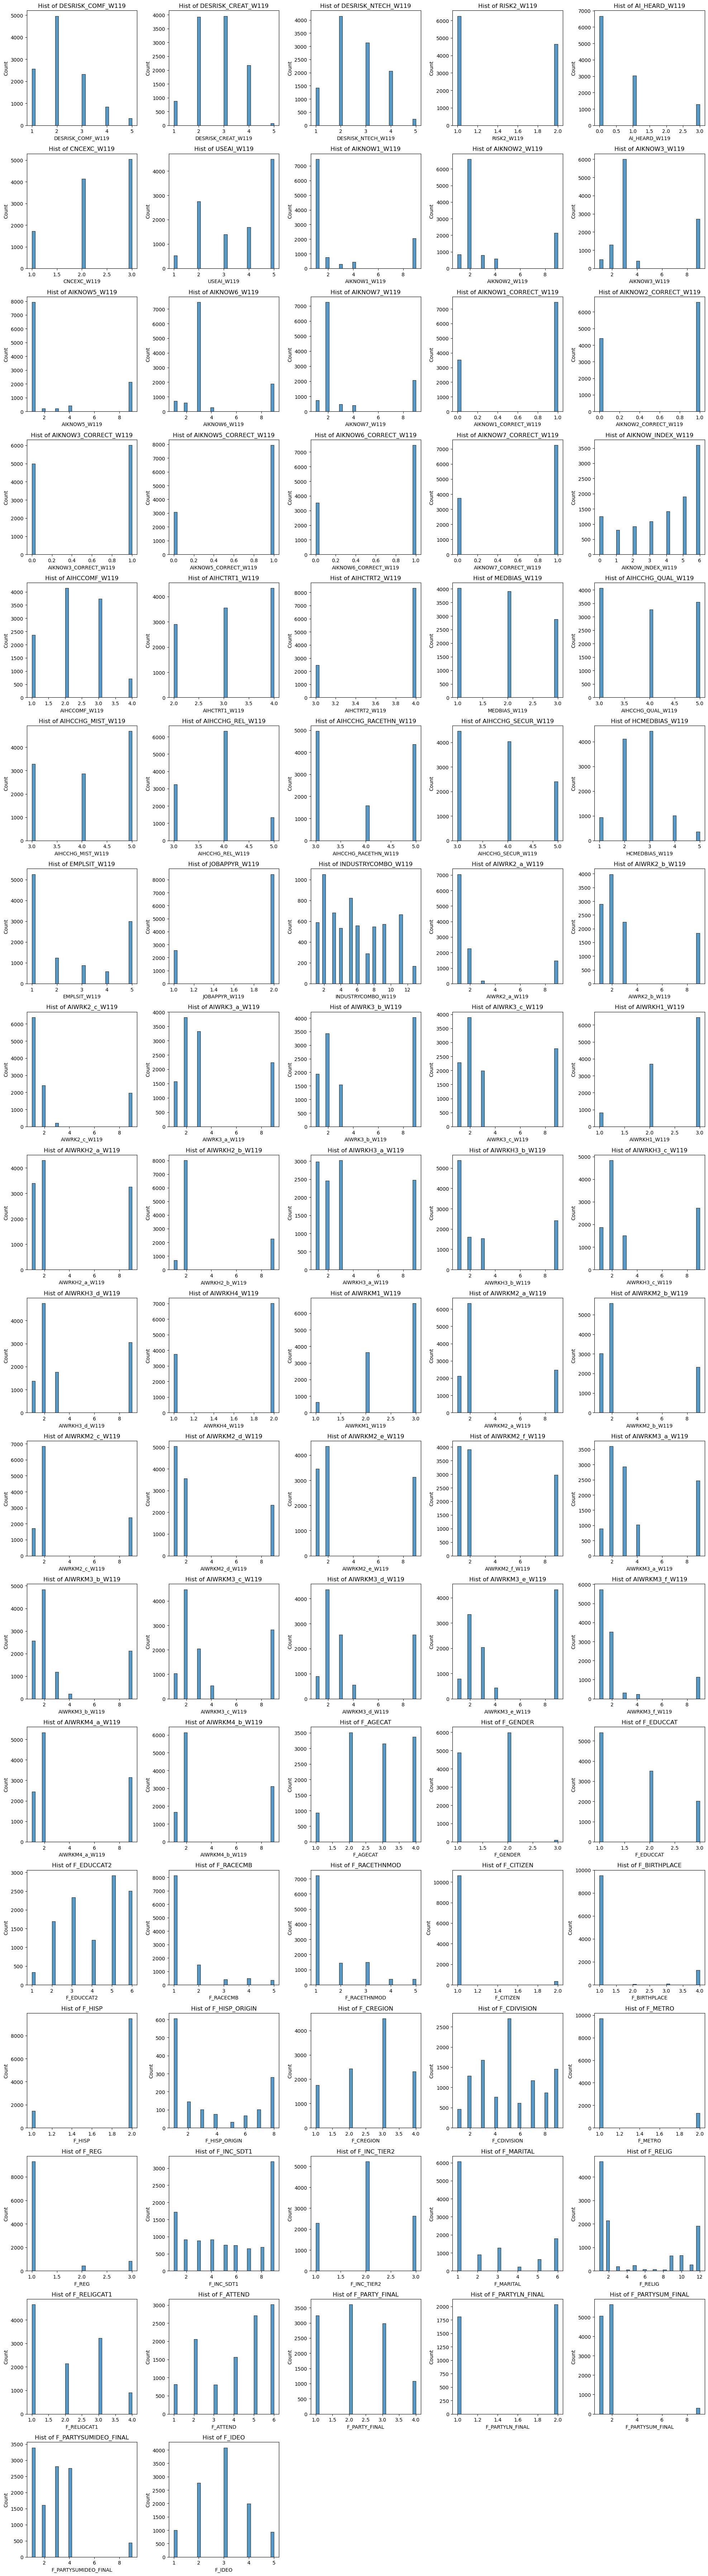


Sample distributions after recoding:


In [9]:
# Recode Likert scale responses to ordinal values
import numpy as np


df_recoded = df_cleaned.copy()

# Recode according to common encoding methods of PEW data

# For attitude/agreement variables (usually 1=strongly agree, 2=somewhat agree, 3=somewhat disagree, 4=strongly disagree)
# Recoded to 4=strongly agree, 3=somewhat agree, 2=somewhat disagree, 1=strongly disagree

attitude_vars = [
    'DESRISK_COMF_W119', 'DESRISK_CREAT_W119', 'DESRISK_NTECH_W119',
    'AIHCCOMF_W119', 'AIHCTRT1_W119', 'AIHCTRT2_W119'
]

for var in attitude_vars:
    if var in df_recoded.columns:

        df_recoded[var] = df_recoded[var].replace({1: 4, 2: 3, 3: 2, 4: 1})

# For frequency variables (1=never, 2=rarely, 3=sometimes, 4=often)
# Keep original coding or adjust as needed

frequency_vars = [
    'USEAI_W119'
]

# For yes/no variables (1=yes, 2=no)
# Recode to 1=yes, 0=no

binary_vars = [
    'AI_HEARD_W119', 'AIKNOW1_CORRECT_W119', 'AIKNOW2_CORRECT_W119', 
    'AIKNOW3_CORRECT_W119', 'AIKNOW5_CORRECT_W119', 'AIKNOW6_CORRECT_W119', 
    'AIKNOW7_CORRECT_W119'
]

for var in binary_vars:
    if var in df_recoded.columns:
        # 1=是->1, 2=否->0
        df_recoded[var] = df_recoded[var].replace({2: 0})

# For the degree of change variable (1=greatly improved, 2=somewhat improved, 3=no change, 4=somewhat worsened, 5=greatly worsened)
# Recode to 5=greatly improved, 4=somewhat improved, 3=no change, 2=somewhat worsened, 1=greatly worsened

change_vars = [
    'AIHCCHG_QUAL_W119', 'AIHCCHG_MIST_W119', 'AIHCCHG_REL_W119', 
    'AIHCCHG_RACETHN_W119', 'AIHCCHG_SECUR_W119'
]

for var in change_vars:
    if var in df_recoded.columns:
        df_recoded[var] = df_recoded[var].replace({1: 5, 2: 4, 4: 2, 5: 1})

print("Likert scale variables have been recoded to ordinal numeric values.")
print("\nRecoding summary:")
print(f"- Attitude variables (reversed): {attitude_vars}")
print(f"- Binary variables (1=Yes, 0=No): {binary_vars}")
print(f"- Change variables (reversed): {change_vars}")

print(f"\nDataset info after recoding:")
print(df_recoded.info())

plot_vars(df_recoded, max_cat_unique=20, bins=30, cols=5, figsize=(20, 4))
print(f"\nSample distributions after recoding:")
# for var in attitude_vars[:3]:
#     if var in df_recoded.columns:
#         print(f"\n{var}:")
#         print(df_recoded[var].value_counts(dropna=False).sort_index())

In [10]:
# Create binary/grouping variables based on age, technology familiarity, and AI skepticism
import numpy as np

df_features = df_recoded.copy()

# Age group variable (age_group)
if 'F_AGECAT' in df_features.columns:
    # Divide the continuous value of age into three groups
    df_features['age_group'] = np.select([
        df_features['F_AGECAT'] <= 2,      # Young Group (18-39)
        df_features['F_AGECAT'].between(3, 4),  # Middle-aged group (40-64)
        df_features['F_AGECAT'] >= 5       # Seniors (65+)
    ], [1, 2, 3], default=np.nan)

    df_features['age_young'] = np.where(df_features['F_AGECAT'] <= 2, 1, 0)
    df_features['age_senior'] = np.where(df_features['F_AGECAT'] >= 5, 1, 0)

# 2. AI acceptance score (AI_acceptance_score)
# Build a composite score based on key AI-related questions
ai_acceptance_vars = []

# Add AI medical trust related variables
healthcare_trust_vars = ['AIHCCOMF_W119', 'AIHCTRT1_W119', 'AIHCTRT2_W119']
available_hc_vars = [var for var in healthcare_trust_vars if var in df_features.columns]
ai_acceptance_vars.extend(available_hc_vars)

# Add AI risk perception variable (reverse coded, higher values ​​are more acceptable)
risk_vars = ['DESRISK_COMF_W119', 'DESRISK_CREAT_W119', 'DESRISK_NTECH_W119']
available_risk_vars = [var for var in risk_vars if var in df_features.columns]
ai_acceptance_vars.extend(available_risk_vars)

# Add AI usage frequency
if 'USEAI_W119' in df_features.columns:
    ai_acceptance_vars.append('USEAI_W119')

# Add AI heard situations
if 'AI_HEARD_W119' in df_features.columns:
    ai_acceptance_vars.append('AI_HEARD_W119')

# Calculating the AI ​​acceptance composite score
if ai_acceptance_vars:

    df_standardized = df_features[ai_acceptance_vars].copy()
    for var in ai_acceptance_vars:
        min_val = df_features[var].min()
        max_val = df_features[var].max()
        if max_val > min_val:
            df_standardized[var] = (df_features[var] - min_val) / (max_val - min_val)
    
    
    df_features['AI_acceptance_score'] = df_standardized.mean(axis=1)
    
    
    df_features['high_ai_acceptance'] = np.where(df_features['AI_acceptance_score'] > 0.5, 1, 0)

# Technological literacy index (tech_literacy_index)
# Based on the problem of adaptability to emerging technologies

tech_literacy_vars = []

# AI knowledge correctness variable
ai_knowledge_vars = ['AIKNOW1_CORRECT_W119', 'AIKNOW2_CORRECT_W119', 'AIKNOW3_CORRECT_W119', 
                     'AIKNOW5_CORRECT_W119', 'AIKNOW6_CORRECT_W119', 'AIKNOW7_CORRECT_W119']
available_knowledge_vars = [var for var in ai_knowledge_vars if var in df_features.columns]
tech_literacy_vars.extend(available_knowledge_vars)


if 'USEAI_W119' in df_features.columns:
    tech_literacy_vars.append('USEAI_W119')


if 'AIKNOW_INDEX_W119' in df_features.columns:
    tech_literacy_vars.append('AIKNOW_INDEX_W119')

# Computing Literacy Index
if tech_literacy_vars:

    df_tech_standardized = df_features[tech_literacy_vars].copy()
    
    for var in tech_literacy_vars:
        if var in available_knowledge_vars:
            # 
            continue
        else:
            
            min_val = df_features[var].min()
            max_val = df_features[var].max()
            if max_val > min_val:
                df_tech_standardized[var] = (df_features[var] - min_val) / (max_val - min_val)
    
  
    df_features['tech_literacy_index'] = df_tech_standardized.mean(axis=1)
    

    df_features['high_tech_literacy'] = np.where(df_features['tech_literacy_index'] > 0.5, 1, 0)

# 4. Create interaction variables
# Young high-tech users

if 'age_young' in df_features.columns and 'high_tech_literacy' in df_features.columns:
    df_features['young_tech_savvy'] = df_features['age_young'] * df_features['high_tech_literacy']

# Older users with low AI acceptance
if 'age_senior' in df_features.columns and 'high_ai_acceptance' in df_features.columns:
    df_features['senior_ai_resistant'] = df_features['age_senior'] * (1 - df_features['high_ai_acceptance'])


if 'age_group' in df_features.columns and 'AI_acceptance_score' in df_features.columns:
    # Create four groups based on age and AI acceptance
    df_features['age_ai_profile'] = np.select([
        (df_features['age_group'] <= 2) & (df_features['AI_acceptance_score'] > 0.5),  # Young + High Acceptance
        (df_features['age_group'] <= 2) & (df_features['AI_acceptance_score'] <= 0.5), # Young + Low Acceptance
        (df_features['age_group'] >= 3) & (df_features['AI_acceptance_score'] > 0.5),  # Older + Highly Acceptable
        (df_features['age_group'] >= 3) & (df_features['AI_acceptance_score'] <= 0.5)  # Older + Low Acceptance
    ], [1, 2, 3, 4], default=np.nan)

new_vars = [col for col in df_features.columns if col not in df_recoded.columns]
print("Newly created variables:")
for var in new_vars:
    print(f"- {var}")

key_vars = ['age_group', 'AI_acceptance_score', 'tech_literacy_index']
print("\nDistribution of key variables:")
for var in key_vars:
    if var in df_features.columns:
        print(f"\n{var}:")
        if var == 'age_group':
            print(df_features[var].value_counts(dropna=False).sort_index())
        else:
            print(df_features[var].describe())


binary_vars = ['high_ai_acceptance', 'high_tech_literacy', 'young_tech_savvy', 'senior_ai_resistant']
print("\nDistribution of binary variables:")
for var in binary_vars:
    if var in df_features.columns:
        print(f"\n{var}:")
        print(df_features[var].value_counts(dropna=False))


print(f"\nDataset shape before feature engineering: {df_recoded.shape}")
print(f"Dataset shape after feature engineering: {df_features.shape}")
print(f"Number of new variables created: {len(new_vars)}")


print(f"\nFinal dataset ready for analysis with {df_features.shape[1]} variables and {df_features.shape[0]} observations.")

Newly created variables:
- age_group
- age_young
- age_senior
- AI_acceptance_score
- high_ai_acceptance
- tech_literacy_index
- high_tech_literacy
- young_tech_savvy
- senior_ai_resistant
- age_ai_profile

Distribution of key variables:

age_group:
age_group
1.0    4444
2.0    6524
NaN      36
Name: count, dtype: int64

AI_acceptance_score:
count    11004.000000
mean         0.467192
std          0.109726
min          0.050000
25%          0.395833
50%          0.467708
75%          0.541667
max          0.906250
Name: AI_acceptance_score, dtype: float64

tech_literacy_index:
count    11004.000000
mean         0.648269
std          0.294663
min          0.000000
25%          0.416667
50%          0.729167
75%          0.906250
max          1.000000
Name: tech_literacy_index, dtype: float64

Distribution of binary variables:

high_ai_acceptance:
high_ai_acceptance
0    7045
1    3959
Name: count, dtype: int64

high_tech_literacy:
high_tech_literacy
1    7619
0    3385
Name: count, dtyp

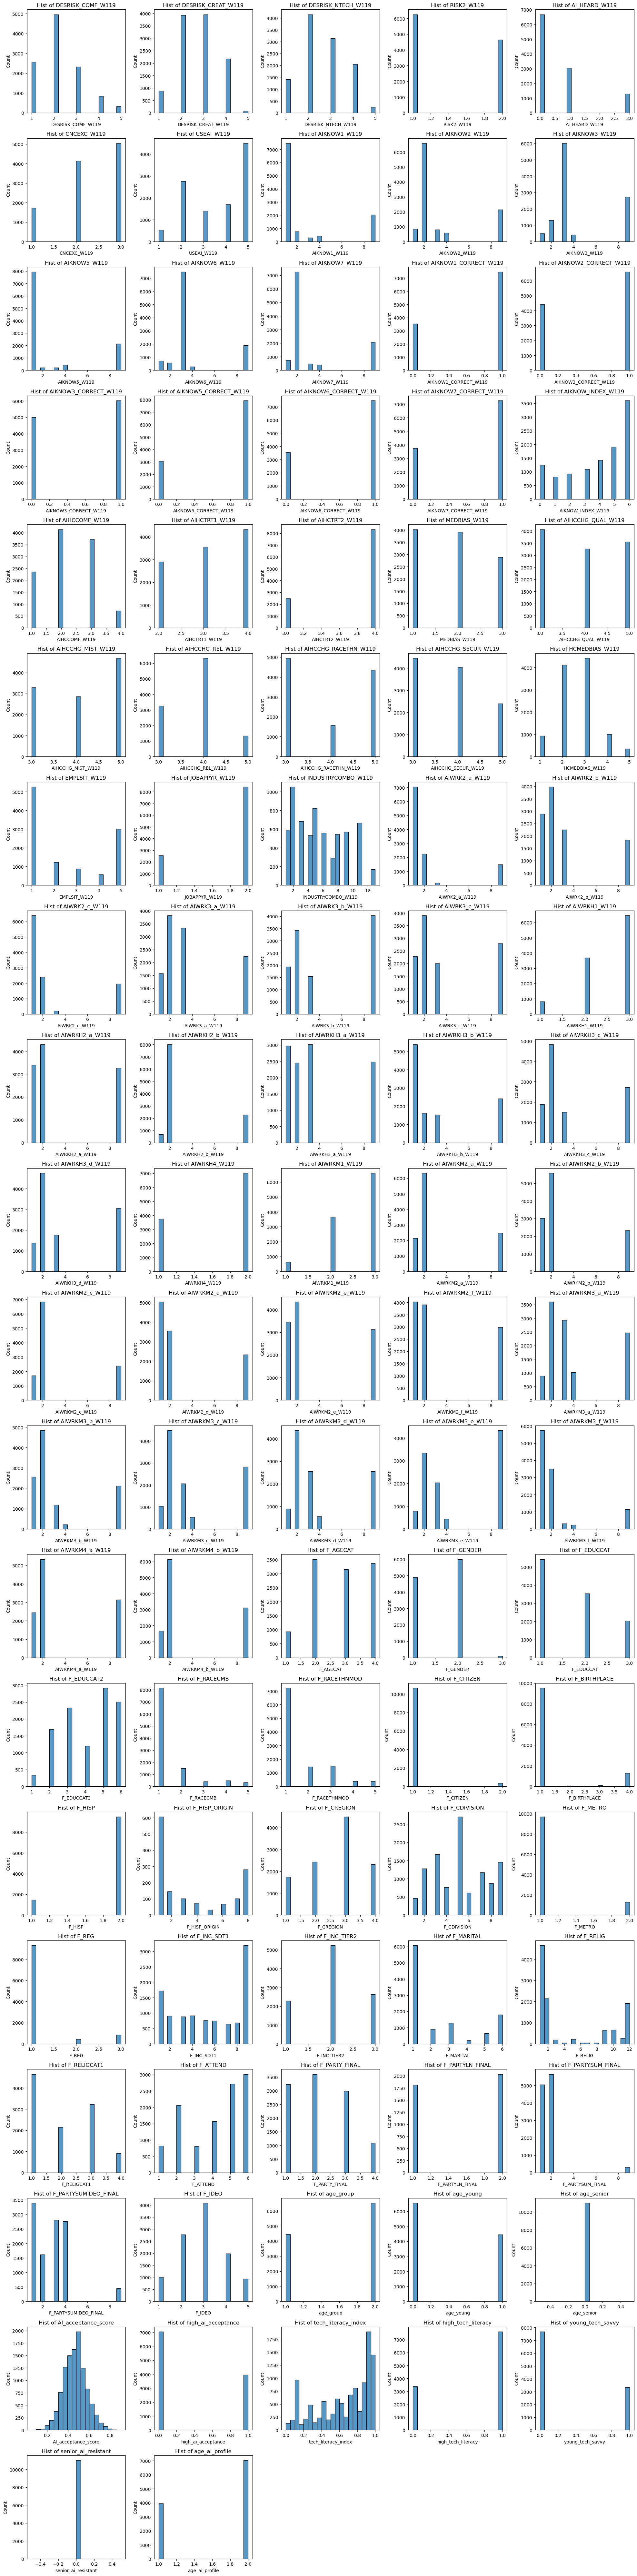

In [11]:


plot_vars(df_features)


In [12]:
df_features.columns

Index(['DESRISK_COMF_W119', 'DESRISK_CREAT_W119', 'DESRISK_NTECH_W119',
       'RISK2_W119', 'AI_HEARD_W119', 'CNCEXC_W119', 'USEAI_W119',
       'AIKNOW1_W119', 'AIKNOW2_W119', 'AIKNOW3_W119', 'AIKNOW5_W119',
       'AIKNOW6_W119', 'AIKNOW7_W119', 'AIKNOW1_CORRECT_W119',
       'AIKNOW2_CORRECT_W119', 'AIKNOW3_CORRECT_W119', 'AIKNOW5_CORRECT_W119',
       'AIKNOW6_CORRECT_W119', 'AIKNOW7_CORRECT_W119', 'AIKNOW_INDEX_W119',
       'AIHCCOMF_W119', 'AIHCTRT1_W119', 'AIHCTRT2_W119', 'MEDBIAS_W119',
       'AIHCCHG_QUAL_W119', 'AIHCCHG_MIST_W119', 'AIHCCHG_REL_W119',
       'AIHCCHG_RACETHN_W119', 'AIHCCHG_SECUR_W119', 'HCMEDBIAS_W119',
       'EMPLSIT_W119', 'JOBAPPYR_W119', 'INDUSTRYCOMBO_W119', 'AIWRK2_a_W119',
       'AIWRK2_b_W119', 'AIWRK2_c_W119', 'AIWRK3_a_W119', 'AIWRK3_b_W119',
       'AIWRK3_c_W119', 'AIWRKH1_W119', 'AIWRKH2_a_W119', 'AIWRKH2_b_W119',
       'AIWRKH3_a_W119', 'AIWRKH3_b_W119', 'AIWRKH3_c_W119', 'AIWRKH3_d_W119',
       'AIWRKH4_W119', 'AIWRKM1_W119', 'AIWRKM2_a

high_tech_literacy
0    0.473693
1    0.464304
Name: AI_acceptance_score, dtype: float64
high_tech_literacy
0    0.468750
1    0.458333
Name: AI_acceptance_score, dtype: float64
high_tech_literacy      
0                   0.25    0.385417
                    0.50    0.468750
                    0.75    0.552083
1                   0.25    0.395833
                    0.50    0.458333
                    0.75    0.531250
Name: AI_acceptance_score, dtype: float64


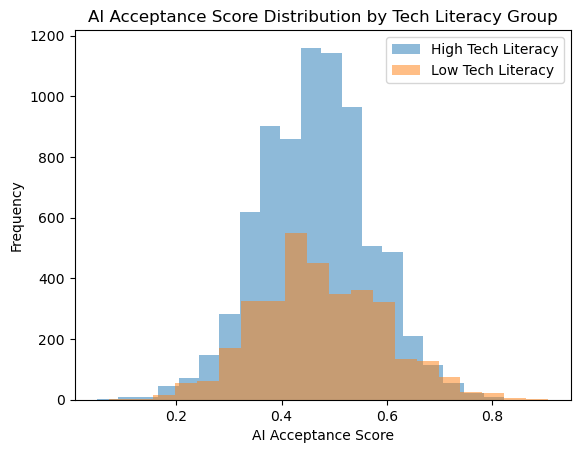

In [13]:
means = df_features.groupby('high_tech_literacy')['AI_acceptance_score'].mean()
medians = df_features.groupby('high_tech_literacy')['AI_acceptance_score'].median()
print(means)
print(medians)
percentiles = df_features.groupby('high_tech_literacy')['AI_acceptance_score'].quantile([0.25, 0.5, 0.75])
print(percentiles)
import matplotlib.pyplot as plt

plt.hist(df_features[df_features['high_tech_literacy']==1]['AI_acceptance_score'], bins=20, alpha=0.5, label='High Tech Literacy')
plt.hist(df_features[df_features['high_tech_literacy']==0]['AI_acceptance_score'], bins=20, alpha=0.5, label='Low Tech Literacy')
plt.legend()
plt.title("AI Acceptance Score Distribution by Tech Literacy Group")
plt.xlabel("AI Acceptance Score")
plt.ylabel("Frequency")
plt.show()



In [14]:
import pandas as pd
cross = pd.crosstab(df_features['high_tech_literacy'], df_features['high_ai_acceptance'], normalize='index')

print(cross)


high_ai_acceptance         0         1
high_tech_literacy                    
0                   0.613294  0.386706
1                   0.652185  0.347815


# Finding
- Tech literacy is associated with a more centralized, moderate-to-high acceptance of AI, but the overall group difference is not dramatic. The main difference lies in the concentration and peak of the distribution, rather than in the existence of two very different populations. 
- Thile there is a theoretical association between tech literacy and openness to AI, the actual effect in this sample is minimal.
- Therefore, increasing tech literacy alone may not substantially enhance AI acceptance among employees. 


F_AGECAT
1.0    0.484691
2.0    0.467489
3.0    0.466607
4.0    0.462506
Name: AI_acceptance_score, dtype: float64 F_AGECAT
1.0    0.479167
2.0    0.458333
3.0    0.458333
4.0    0.458333
Name: AI_acceptance_score, dtype: float64 F_AGECAT      
1.0       0.25    0.406250
          0.50    0.479167
          0.75    0.562500
2.0       0.25    0.395833
          0.50    0.458333
          0.75    0.541667
3.0       0.25    0.395833
          0.50    0.458333
          0.75    0.541667
4.0       0.25    0.385417
          0.50    0.458333
          0.75    0.531250
Name: AI_acceptance_score, dtype: float64


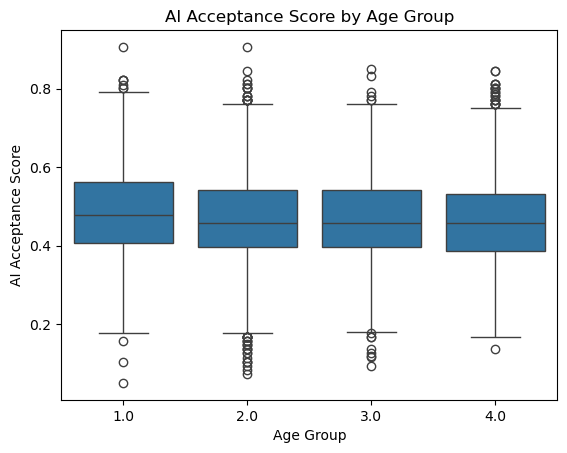

In [15]:
means = df_features.groupby('F_AGECAT')['AI_acceptance_score'].mean()
medians = df_features.groupby('F_AGECAT')['AI_acceptance_score'].median()
percentiles = df_features.groupby('F_AGECAT')['AI_acceptance_score'].quantile([0.25, 0.5, 0.75])
print(means, medians, percentiles)


sns.boxplot(x='F_AGECAT', y='AI_acceptance_score', data=df_features)
plt.title('AI Acceptance Score by Age Group')
plt.xlabel('Age Group')
plt.ylabel('AI Acceptance Score')
plt.show()


F_PARTY_FINAL
1.0    0.461410
2.0    0.470077
3.0    0.469945
4.0    0.468444
Name: AI_acceptance_score, dtype: float64


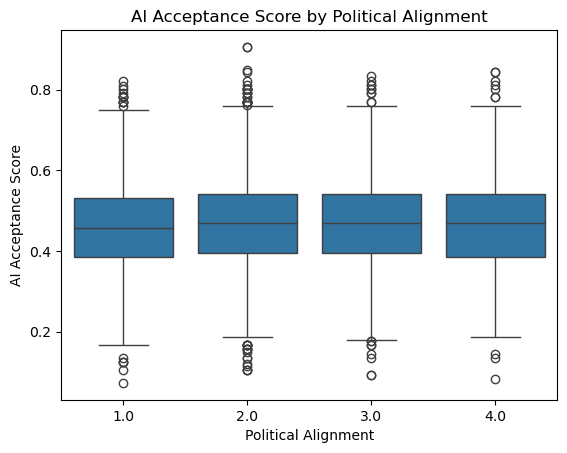

F_PARTY_FINAL
1.0    0.461410
2.0    0.470077
3.0    0.469945
4.0    0.468444
Name: AI_acceptance_score, dtype: float64


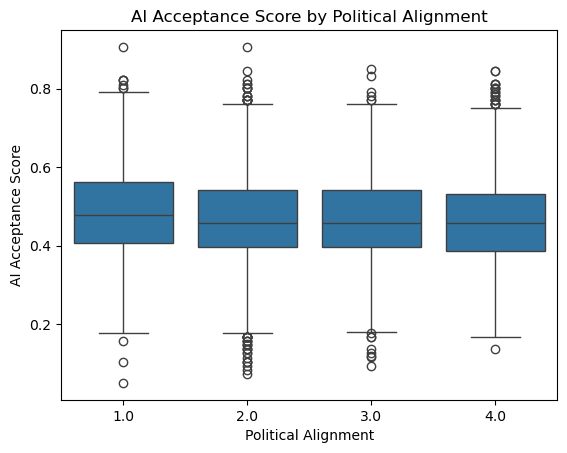

In [16]:
party_means = df_features.groupby('F_PARTY_FINAL')['AI_acceptance_score'].mean()
print(party_means)
sns.boxplot(x='F_PARTY_FINAL', y='AI_acceptance_score', data=df_features)
plt.title('AI Acceptance Score by Political Alignment')
plt.xlabel('Political Alignment')
plt.ylabel('AI Acceptance Score')
plt.show()
party_means = df_features.groupby('F_PARTY_FINAL')['AI_acceptance_score'].mean()
print(party_means)
sns.boxplot(x='F_AGECAT', y='AI_acceptance_score', data=df_features)
plt.title('AI Acceptance Score by Political Alignment')
plt.xlabel('Political Alignment')
plt.ylabel('AI Acceptance Score')
plt.show()


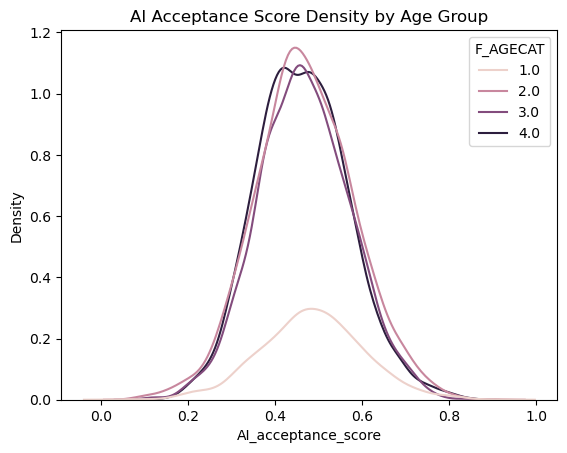

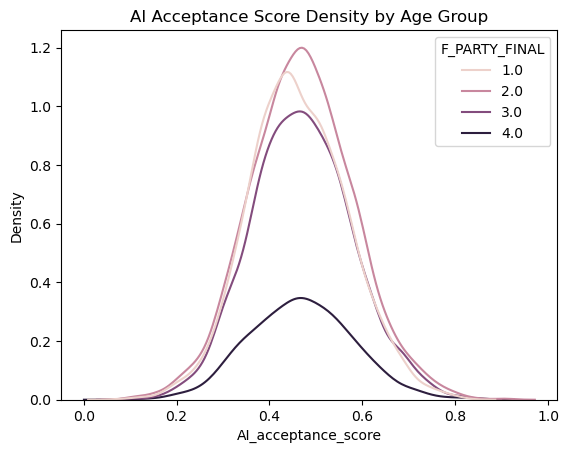

In [17]:

sns.kdeplot(data=df_features, x='AI_acceptance_score', hue='F_AGECAT')
plt.title('AI Acceptance Score Density by Age Group')
plt.show()

sns.kdeplot(data=df_features, x='AI_acceptance_score', hue='F_PARTY_FINAL')
plt.title('AI Acceptance Score Density by Age Group')
plt.show()
from statsmodels.distributions.empirical_distribution import ECDF
import numpy as np




# Finding
- Only the youngest group showed low and scattered characteristics in AI acceptance, while there was almost no difference between the other age groups, indicating that the impact of age was mainly reflected within the young group.
- The distribution of AI acceptance among members of mainstream parties is more concentrated and consistent, while the attitudes of people in the 4.0 political group towards AI are more dispersed and divergent, indicating that political inclination has an important impact on AI acceptance.

high_tech_literacy         0         1
F_AGECAT                              
1.0                 0.501463  0.478148
2.0                 0.483609  0.462273
3.0                 0.471586  0.464569
4.0                 0.463119  0.462106
high_tech_literacy         0         1
F_AGECAT                              
1.0                 0.241379  0.118087
2.0                 0.173458  0.106215
3.0                 0.135224  0.094643
4.0                 0.108271  0.084929


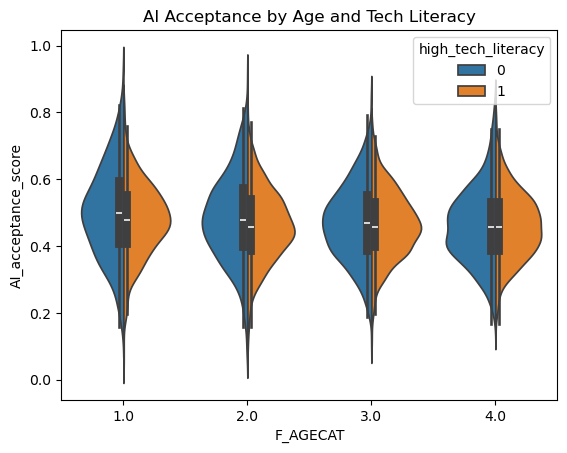

In [18]:

pivot = df_features.pivot_table(
    index='F_AGECAT', 
    columns='high_tech_literacy', 
    values='AI_acceptance_score', 
    aggfunc='mean'
)
print(pivot)

df_features['high_ai_acceptance'] = df_features['AI_acceptance_score'] > 0.6
crosstab = pd.crosstab(
    df_features['F_AGECAT'], df_features['high_tech_literacy'], df_features['high_ai_acceptance'], 
    aggfunc='mean'
)
print(crosstab)

sns.violinplot(
    data=df_features, x='F_AGECAT', y='AI_acceptance_score',
    hue='high_tech_literacy', split=True
)
plt.title('AI Acceptance by Age and Tech Literacy')
plt.show()


The combined group analysis shows that among different age groups, the average AI acceptance of people with low technical literacy (high_tech_literacy=0) is slightly higher than that of people with high technical literacy (high_tech_literacy=1), and this difference does not increase significantly between groups with increasing age. Especially in the older group (F_AGECAT=4), the AI ​​acceptance of people with high and low technical literacy is basically the same.

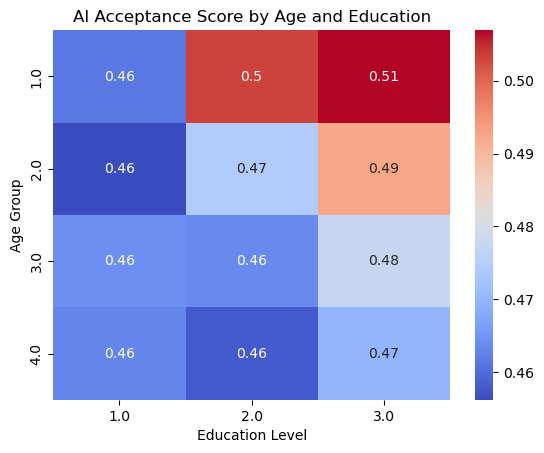

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df_features.pivot_table(
    index='F_AGECAT',
    columns='F_EDUCCAT',
    values='AI_acceptance_score',
    aggfunc='mean'
)
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("AI Acceptance Score by Age and Education")
plt.xlabel("Education Level")
plt.ylabel("Age Group")
plt.show()






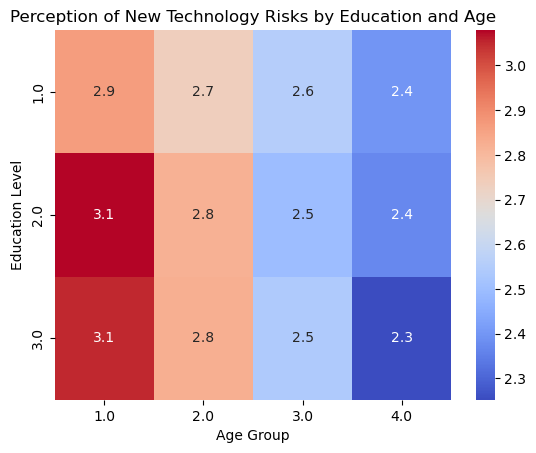

In [20]:



# 1. Descriptive Statistics
key_vars = ['DESRISK_COMF_W119', 'DESRISK_NTECH_W119', 'AIHCCHG_QUAL_W119', 'AIHCCHG_RACETHN_W119', 'MEDBIAS_W119']



# Heatmap: AI risk perception by education and age
pivot = df_features.pivot_table(
    index='F_EDUCCAT', 
    columns='F_AGECAT', 
    values='DESRISK_NTECH_W119', 
    aggfunc='mean'
)
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("Perception of New Technology Risks by Education and Age")
plt.xlabel("Age Group")
plt.ylabel("Education Level")
plt.show()



- There is a clear declining trend in risk perception with increasing age
- In general, people with higher education have a slightly higher risk perception of new technologies
- This suggests that younger and more highly educated individuals are more attuned to risks associated with new technologies

In [21]:
# Prepare data
target = 'high_ai_acceptance'
excluded_cols = ['AI_acceptance_score', 
                 'tech_literacy_index', 
                 'high_ai_acceptance',    
                 'AI_acceptance_score',
                 'high_ai_acceptance',
                 'tech_literacy_index',
                 'high_tech_literacy',
                 'young_tech_savvy',
                 'senior_ai_resistant',
                 'age_ai_profile']
X = df_features.drop(columns=excluded_cols).select_dtypes(include='number').fillna(0)
y = df_features[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)


In [22]:
#Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

In [23]:
# Evaluate models
# Step 3: Evaluation
results = []

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    
    # Predict and get probabilities in one clean step
    y_pred = pipe.predict(X_test)
    
    try:
        y_prob = pipe.predict_proba(X_test)[:, 1]
    except:
        y_score = pipe.decision_function(X_test)
        y_prob = (y_score - y_score.min()) / (y_score.max() - y_score.min())

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    })
# Convert results to DataFrame
results_df = pd.DataFrame(results)

#  by ROC AUC (descending)
results_df_sorted = results_df.sort_values(by='ROC AUC', ascending=False).reset_index(drop=True)

#  sorted results
print("Model performance ranked from best to worst (by ROC AUC):")
print(results_df_sorted)

Model performance ranked from best to worst (by ROC AUC):
                 Model  Accuracy   ROC AUC
0    Gradient Boosting  0.980012  0.996688
1                  SVM  0.953362  0.986759
2  Logistic Regression  0.981829  0.985020
3        Random Forest  0.911569  0.972892
4     Ridge Classifier  0.907935  0.965150
5                  KNN  0.890975  0.737665


# Finds

Gradient Boosting

- Highest ROC AUC: 0.996

- Accuracy: 97.40%

- Best overall model for predicting AI acceptance.

- Recommended for deployment in the HR decision-support tool.

Support Vector Machine (SVM)

- ROC AUC: 0.986

- Accuracy: 95.21%

- Strong non-linear model with good performance.

- Slightly less interpretable than logistic regression.

Logistic Regression

- ROC AUC: 0.985

- Highest Accuracy: 98.18%

- Very interpretable model.

- Ideal for HR reports and business presentations.

Random Forest

- ROC AUC: 0.971

- Accuracy: 91.13%

- Good model, but outperformed by Gradient Boosting.

Ridge Classifier

- ROC AUC: 0.965

- Accuracy: 90.79%

- Simple and fast, but less powerful for this task.

K-Nearest Neighbors (KNN)

- Lowest ROC AUC: 0.796

- Accuracy: 89.25%

- Weakest model.

- Not suitable for high-dimensional classification in this use case.

In [24]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Fit your best model
best_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)

# Get feature importances using permutation method
result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Create sorted importance dataframe
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)
print("Top 15 Features (by Mean Permutation Importance):\n")
print(importance_df.head(15).to_string(index=False))


Top 15 Features (by Mean Permutation Importance):

             feature  importance_mean  importance_std
       AIHCTRT1_W119         0.070866        0.003301
       AIHCTRT2_W119         0.061205        0.002720
          USEAI_W119         0.060630        0.003046
       AI_HEARD_W119         0.056239        0.003464
  DESRISK_NTECH_W119         0.047577        0.003096
   DESRISK_COMF_W119         0.043489        0.002243
       AIHCCOMF_W119         0.038219        0.002237
  DESRISK_CREAT_W119         0.032980        0.001829
      HCMEDBIAS_W119         0.000818        0.000429
       JOBAPPYR_W119         0.000575        0.000316
AIHCCHG_RACETHN_W119         0.000545        0.000402
         CNCEXC_W119         0.000515        0.000333
       F_HISP_ORIGIN         0.000454        0.000151
        AIKNOW1_W119         0.000333        0.000163
      AIWRKH3_d_W119         0.000273        0.000316


# Finds

- Trust in AI for treatment is the strongest predictor of AI acceptance.

- Frequent AI users are much more likely to support AI in the workplace.

- Age combined with acceptance profile is a key demographic driver.

- Awareness of AI (just hearing about it) significantly impacts acceptance.

- Low risk perception and high comfort with AI are strong positive indicators.

- Trust in AI in healthcare overall boosts workplace acceptance.

- AI knowledge correctness and employment type have low influence.

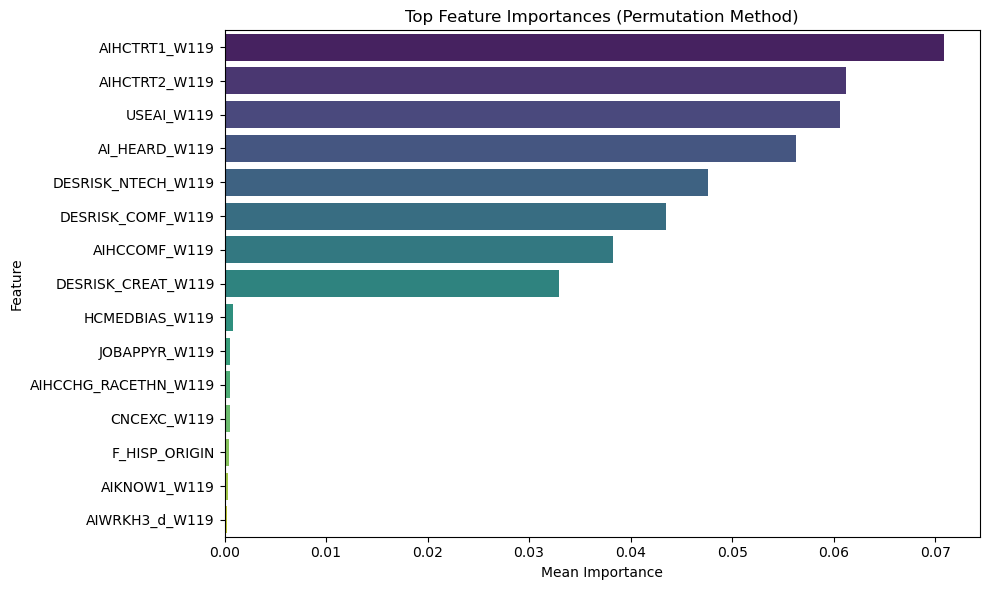

In [25]:
# Plot top 15 features
top_n = 15
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=importance_df.head(top_n), palette='viridis')
plt.title('Top Feature Importances (Permutation Method)')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

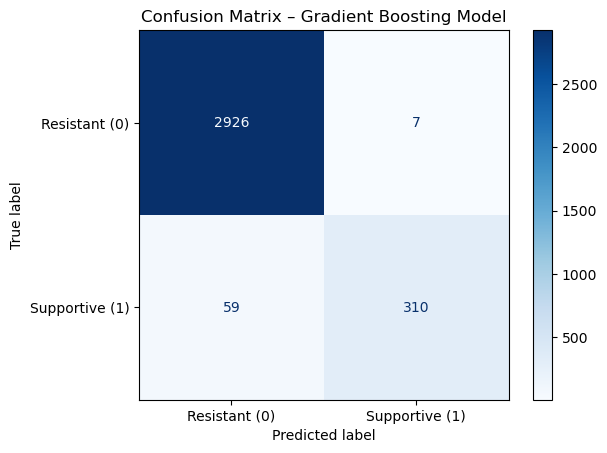

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict with top model
y_pred = best_model.predict(X_test)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Resistant (0)', 'Supportive (1)'])

# Plot
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Gradient Boosting Model')
plt.show()


## 5-fold CV

In [47]:
from sklearn.model_selection import StratifiedKFold, cross_validate

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_cv = []

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    scores = cross_validate(
        pipe, X, y,
        cv=cv,
        scoring=['accuracy', 'roc_auc'],
        n_jobs=-1,
        return_train_score=False
    )
    results_cv.append({
        'Model': name,
        'CV Accuracy Mean': scores['test_accuracy'].mean(),
        'CV Accuracy Std': scores['test_accuracy'].std(),
        'CV ROC AUC Mean': scores['test_roc_auc'].mean(),
        'CV ROC AUC Std': scores['test_roc_auc'].std()
    })

results_cv_df = pd.DataFrame(results_cv).sort_values(by='CV ROC AUC Mean', ascending=False).reset_index(drop=True)

print("5-fold Stratified CV Results (ranked by ROC AUC mean):")
print(results_cv_df)




5-fold Stratified CV Results (ranked by ROC AUC mean):
                 Model  CV Accuracy Mean  CV Accuracy Std  CV ROC AUC Mean  \
0    Gradient Boosting          0.980643         0.001740         0.996683   
1                  SVM          0.955925         0.002510         0.985952   
2  Logistic Regression          0.982370         0.003685         0.984433   
3        Random Forest          0.914122         0.002219         0.974235   
4     Ridge Classifier          0.909760         0.001729         0.968161   
5                  KNN          0.891494         0.001697         0.731968   

   CV ROC AUC Std  
0        0.001121  
1        0.001866  
2        0.002671  
3        0.004089  
4        0.003494  
5        0.012932  


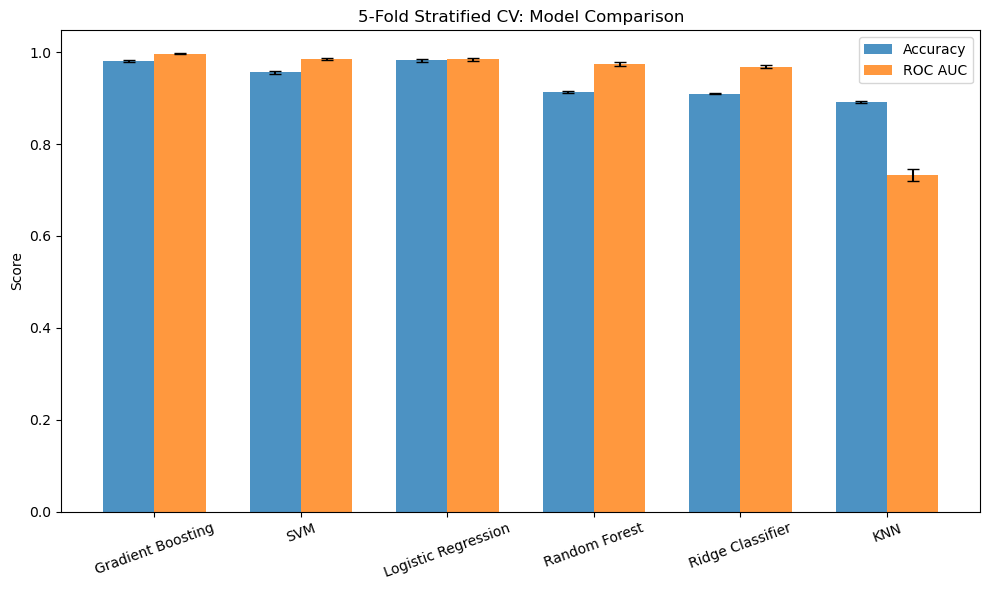

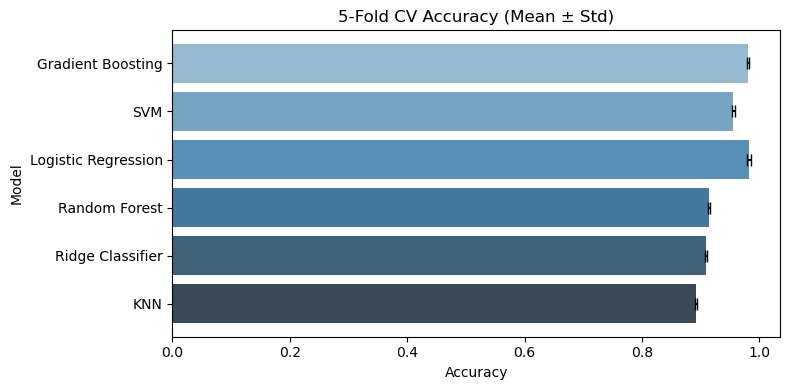

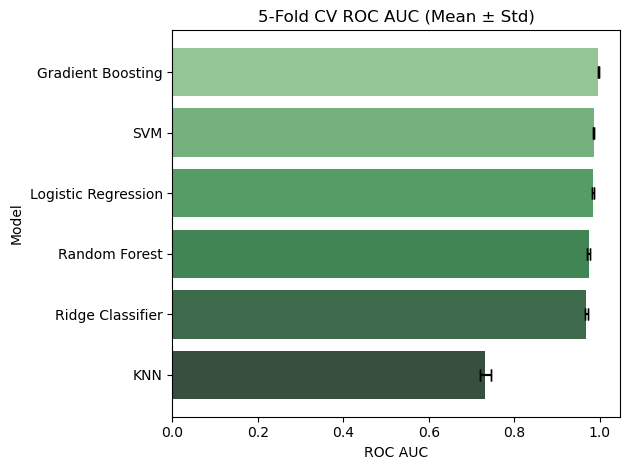

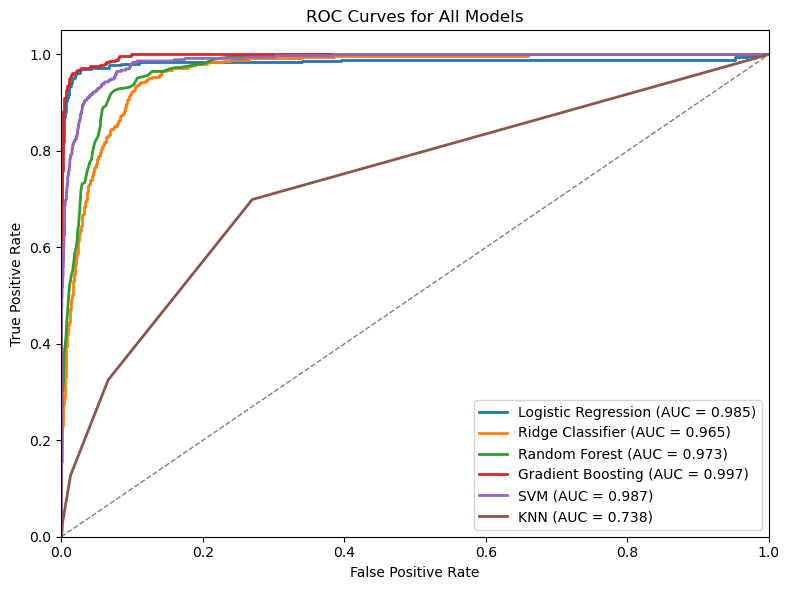

In [28]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
indices = np.arange(len(results_cv_df))

# Accuracy bar
acc_bar = ax.bar(indices - bar_width/2, results_cv_df['CV Accuracy Mean'], 
                 bar_width, yerr=results_cv_df['CV Accuracy Std'],
                 label='Accuracy', alpha=0.8, capsize=4)

# ROC AUC bar
auc_bar = ax.bar(indices + bar_width/2, results_cv_df['CV ROC AUC Mean'], 
                 bar_width, yerr=results_cv_df['CV ROC AUC Std'],
                 label='ROC AUC', alpha=0.8, capsize=4)

ax.set_xticks(indices)
ax.set_xticklabels(results_cv_df['Model'], rotation=20)
ax.set_ylabel('Score')
ax.set_title('5-Fold Stratified CV: Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

import seaborn as sns

plt.figure(figsize=(8, 4))
sns.barplot(x='CV Accuracy Mean', y='Model', data=results_cv_df,
            palette='Blues_d', orient='h')
plt.errorbar(results_cv_df['CV Accuracy Mean'], results_cv_df['Model'], 
             xerr=results_cv_df['CV Accuracy Std'], fmt='none', c='black', capsize=4)
plt.title('5-Fold CV Accuracy (Mean ± Std)')
plt.xlabel('Accuracy')
plt.tight_layout()
plt.show()
sns.barplot(x='CV ROC AUC Mean', y='Model', data=results_cv_df,
            palette='Greens_d', orient='h')
plt.errorbar(results_cv_df['CV ROC AUC Mean'], results_cv_df['Model'], 
             xerr=results_cv_df['CV ROC AUC Std'], fmt='none', c='black', capsize=4)
sns.barplot(x='CV ROC AUC Mean', y='Model', data=results_cv_df,
            palette='Greens_d', orient='h')
plt.errorbar(results_cv_df['CV ROC AUC Mean'], results_cv_df['Model'], 
             xerr=results_cv_df['CV ROC AUC Std'], fmt='none', c='black', capsize=4)
plt.title('5-Fold CV ROC AUC (Mean ± Std)')
plt.xlabel('ROC AUC')
plt.tight_layout()
plt.show()


from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    try:
        y_prob = pipe.predict_proba(X_test)[:, 1]
    except AttributeError:
        # For models without predict_proba (like SVM with no probability=True)
        y_score = pipe.decision_function(X_test)
        # Normalize scores to [0, 1]
        y_prob = (y_score - y_score.min()) / (y_score.max() - y_score.min())
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()



 # Interpretation
 - The Global Variable Importance Chart shows the importance and direction (positive/negative impact) of each variable across all employee samples.
 - It helps answer the question: "Overall, which features determine AI acceptance?"
### Explanation of Top SHAP Features (Model Interpretability)

Below are the top features ranked by SHAP importance, along with what each variable represents:

| Feature Name           | Description |
|------------------------|-------------|
| **AIHCTRT1_W119**      | Trust in AI to assist with **diagnosis** decisions in healthcare. |
| **AIHCTRT2_W119**      | Trust in AI to assist with **treatment** decisions in healthcare. |
| **USEAI_W119**         | Frequency of **personal use of AI technologies** (e.g., chatbots, recommendation systems). |
| **AI_HEARD_W119**      | Awareness of AI — whether the respondent has **heard of AI** applications before. |
| **DESRISK_NTECH_W119** | Belief that AI can **reduce technical risks**, such as errors in operations. |
| **DESRISK_COMF_W119**  | Self-reported **comfort level** in using AI-based systems. |
| **AIHCCOMF_W119**      | Comfort with using **AI in a healthcare context** (e.g., for diagnostics or information). |
| **DESRISK_CREAT_W119** | Belief that AI can **enhance creativity** or support creative tasks. |
| **HCMEDBIAS_W119**     | Belief about whether AI will **reduce bias in healthcare decisions**. |
| **JOBAPPYR_W119**      | Number of **years the respondent has been happy in their current job**. |
| **AIHCCHG_RACETHN_W119** | Belief that AI will **impact race/ethnicity fairness** in healthcare. |
| **CNCEXC_W119**        | Whether the respondent feels **excluded from technology** (digital divide indicator). |
| **F_HISP_ORIGIN**      | Respondent’s **Hispanic origin** background. |
| **AIKNOW1_W119**       | One of the factual **AI knowledge quiz questions**, used to assess understanding of AI. |
| **AIWRKH3_d_W119**     | Whether AI is used in the respondent’s **workplace department D** (e.g., finance, HR, etc.). |

> These features were identified as most influential in predicting employees' AI acceptance levels using SHAP values from a Gradient Boosting model.
   
 

 97%|=================== | 10694/11004 [00:22<00:00]       

Top Features by SHAP Importance:
               Feature  Mean SHAP Value
22       AIHCTRT2_W119         1.288003
6           USEAI_W119         1.260738
21       AIHCTRT1_W119         1.229506
4        AI_HEARD_W119         1.095736
2   DESRISK_NTECH_W119         0.905910
0    DESRISK_COMF_W119         0.870391
20       AIHCCOMF_W119         0.865848
1   DESRISK_CREAT_W119         0.723621
78           F_MARITAL         0.026239
45      AIWRKH3_d_W119         0.018774
69        F_BIRTHPLACE         0.016548
3           RISK2_W119         0.011304
65          F_EDUCCAT2         0.010205
79             F_RELIG         0.010204
7         AIKNOW1_W119         0.010196


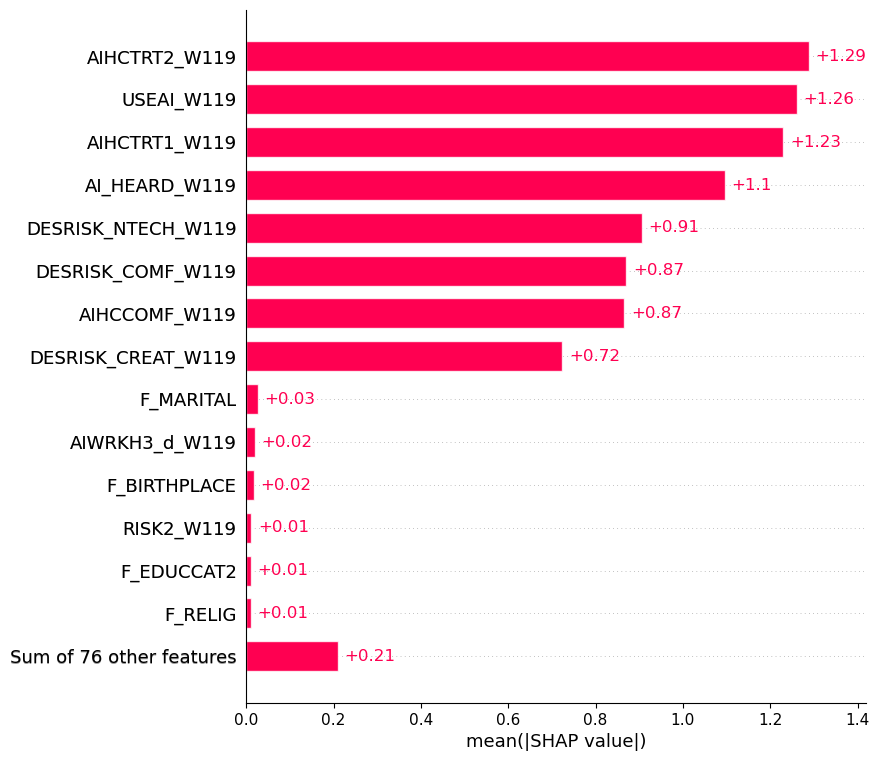

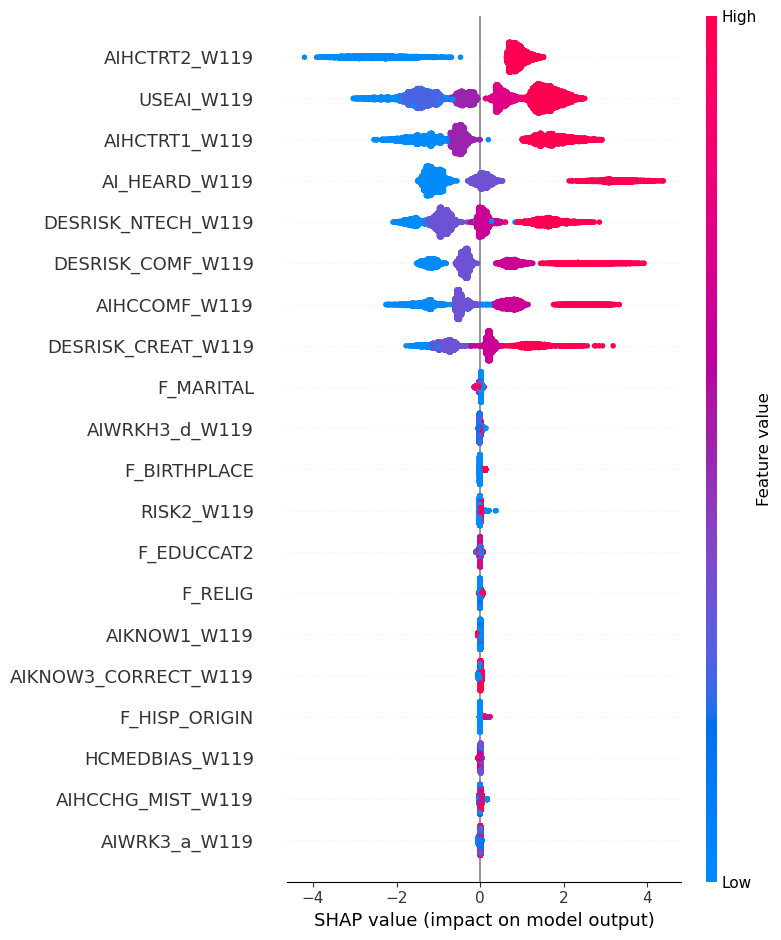

In [29]:
import shap
import numpy as np
import pandas as pd


model = GradientBoostingClassifier(n_estimators=200, random_state=42)
model.fit(X, y)


explainer = shap.Explainer(model, X)
shap_values = explainer(X)


shap_importance = np.abs(shap_values.values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean SHAP Value': shap_importance
}).sort_values(by='Mean SHAP Value', ascending=False)

print("Top Features by SHAP Importance:")
print(importance_df.head(15))


shap.plots.bar(shap_values, max_display=15)
shap.summary_plot(shap_values, X)


## HR Use Case: Predicting and Understanding AI Acceptance
### Scenario
Human Resources wants to assess how likely an employee is to accept AI in the workplace. While the full dataset contains dozens of features, using all of them in a practical setting (e.g., a form or app) is often impractical or overwhelming.

To address this, we select only the most important predictors, based on SHAP analysis, to build a lightweight model that is interpretable and deployable for HR teams. These top features capture the majority of the predictive power while remaining user-friendly for survey design.

After an employee completes the short questionnaire, the model (a Gradient Boosting Classifier trained on top N features) provides:

- A predicted probability of AI acceptance

- A personalized explanation using SHAP values, indicating why the employee is likely to accept or resist AI


In [39]:
import pandas as pd
import shap
from sklearn.ensemble import GradientBoostingClassifier
from ipywidgets import interact, IntSlider, VBox, HBox, Label

# 
top_features = [
    'AIHCTRT1_W119',  # Trust in AI for Diagnosis
    'AIHCTRT2_W119',  # Trust in AI for Treatment
    'USEAI_W119',     # Frequency of AI Usage
    'AI_HEARD_W119',  # Heard of AI
    'DESRISK_NTECH_W119',  # Belief: AI reduces technical risk
    'DESRISK_COMF_W119',   # Comfort using AI
    'DESRISK_CREAT_W119',  # Belief: AI improves creativity
    'AIHCCOMF_W119'        # Comfort with AI in healthcare
]


labels = {
    'AIHCTRT1_W119': 'Trust in AI for Diagnosis (0–4)',
    'AIHCTRT2_W119': 'Trust in AI for Treatment (0–4)',
    'USEAI_W119': 'How often do you use AI (0–5)',
    'AI_HEARD_W119': 'Have you heard of AI? (0–3)',
    'DESRISK_NTECH_W119': 'AI reduces technical risks (0–5)',
    'DESRISK_COMF_W119': 'How comfortable are you with AI? (0–5)',
    'DESRISK_CREAT_W119': 'AI helps with creativity (0–5)',
    'AIHCCOMF_W119': 'Comfort with AI in healthcare (0–4)'
}



sliders = {
    key: IntSlider(
        min=0,
        max=5 if 'USEAI' in key or 'DESRISK' in key else 4 if 'AIHCCOMF' in key or 'AIHCTRT' in key else 3,
        value=2,
        description=labels[key],
        layout=Layout(width='auto'),
        style={'description_width': 'initial'}
    )
    for key in labels
}


VBox(list(sliders.values()))



model_small = GradientBoostingClassifier(n_estimators=200, random_state=42)
model_small.fit(X[top_features], y)
explainer = shap.Explainer(model_small, X[top_features])


def predict_and_explain(**kwargs):
    new_X = pd.DataFrame([kwargs])
    prob = model_small.predict_proba(new_X)[0][1]
    print(f"\n🔍 Predicted AI acceptance probability: {prob:.2f}")
    
    # SHAP waterfall plot
    shap_values = explainer(new_X)
    shap.plots.waterfall(shap_values[0])

interact(predict_and_explain, **sliders)


interactive(children=(IntSlider(value=2, description='Trust in AI for Diagnosis (0–4)', layout=Layout(width='a…

<function __main__.predict_and_explain(**kwargs)>

# Persona 1: 
This employee is **predicted to have a high likelihood of accepting AI**, driven primarily by:
- strong **trust in AI decision-making** (especially in healthcare),
- high **usage frequency** and **awareness**,
- and a generally **positive comfort level** across contexts.



🔍 Predicted AI acceptance probability: 0.69


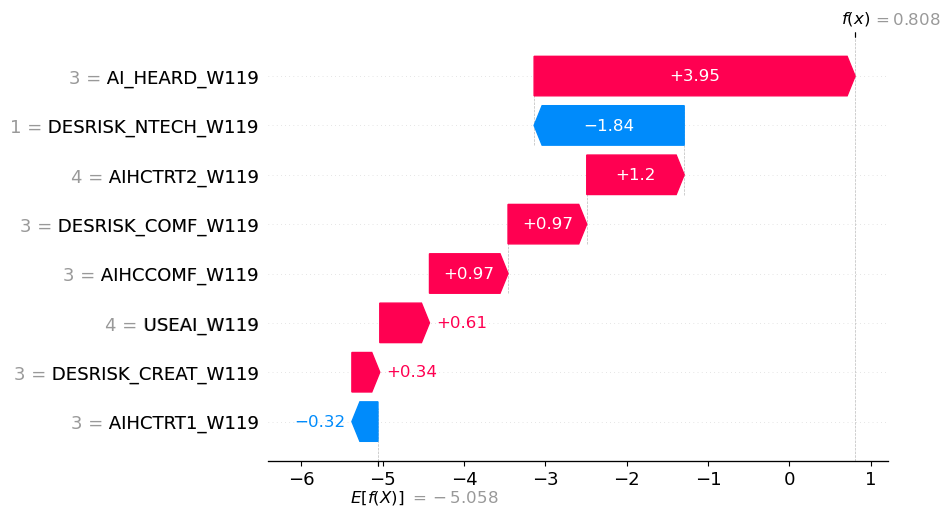

In [36]:

staff_input = {
    'AIHCTRT1_W119': 3,  # Trust in AI for Diagnosis
    'AIHCTRT2_W119': 4,  # Trust in AI for Treatment
    'USEAI_W119': 4,     # Frequency of AI Usage
    'AI_HEARD_W119': 3,  # Heard of AI
    'DESRISK_NTECH_W119': 1,  # AI reduces technical risks
    'DESRISK_COMF_W119': 3,   # Comfort using AI
    'DESRISK_CREAT_W119': 3,  # AI helps with creativity
    'AIHCCOMF_W119': 3        # Comfort with AI in healthcare
}

def predict_and_explain_manual(input_dict):
    new_X = pd.DataFrame([input_dict])
    
    prob = model_small.predict_proba(new_X)[0][1]
    print(f"\n🔍 Predicted AI acceptance probability: {prob:.2f}")
    
    shap_values = explainer(new_X)
    shap.plots.waterfall(shap_values[0])

predict_and_explain_manual(staff_input)


# Persona 2: 
This employee shows a **high level of trust in AI's capabilities in healthcare**, especially in **diagnosis and treatment** (both 4/4), and is **highly aware** of AI technologies (3/3).

However, their **actual comfort using AI** is low (1/5), and they **do not believe AI improves creativity or reduces risk**, suggesting a cognitive gap:  
> *“AI is trustworthy in specific domains (like medicine), but I’m personally uncomfortable or unconvinced about using it in general.”*

Their **AI usage frequency (2/5)** is modest — they might be familiar with AI but haven’t engaged with it deeply in everyday work.



🔍 Predicted AI acceptance probability: 0.15


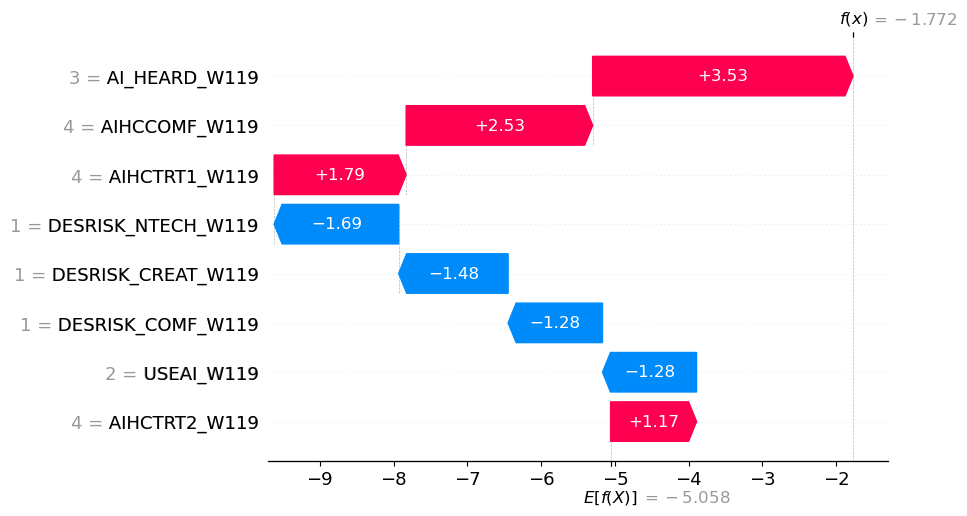

In [41]:

staff_input = {
    'AIHCTRT1_W119': 4,  # Trust in AI for Diagnosis
    'AIHCTRT2_W119': 4,  # Trust in AI for Treatment
    'USEAI_W119': 2,     # Frequency of AI Usage
    'AI_HEARD_W119': 3,  # Heard of AI
    'DESRISK_NTECH_W119': 1,  # AI reduces technical risks
    'DESRISK_COMF_W119': 1,   # Comfort using AI
    'DESRISK_CREAT_W119': 1,  # AI helps with creativity
    'AIHCCOMF_W119': 4        # Comfort with AI in healthcare
}

def predict_and_explain_manual(input_dict):
    new_X = pd.DataFrame([input_dict])
    
    prob = model_small.predict_proba(new_X)[0][1]
    print(f"\n🔍 Predicted AI acceptance probability: {prob:.2f}")
    
    shap_values = explainer(new_X)
    shap.plots.waterfall(shap_values[0])

predict_and_explain_manual(staff_input)


# Persona 3:
Despite several strong indicators of familiarity and comfort with AI, this staff member is predicted to have a **moderate-to-low likelihood of accepting AI**. Here's a breakdown of the key traits:
# Positive Indicators:
- Very frequent AI usage (5/5): Indicates strong personal experience with AI tools in daily life.
- Full awareness (3/3): Has heard of AI across multiple contexts, suggesting good exposure.
- High trust in AI for diagnosis (4/4): Shows confidence in AI's analytical abilities in healthcare.
- Very comfortable using AI in general (5/5).
- Believes AI reduces technical risks (4/5).
- Perceives AI as helpful for creativity (3/5).

# Key Limiting Factor:
- **Low comfort with AI in healthcare (1/4)**:  
  This is a major contributing factor pulling the predicted score down. While the employee trusts AI for diagnosis, they feel uncomfortable when AI is used in actual healthcare settings — a **critical contradiction** that heavily impacts the model’s prediction.

- **Moderate trust in AI for treatment (2/4)**:  
  Suggests hesitancy when AI moves beyond assisting diagnosis to making treatment decisions.

This employee is AI-aware and tech-savvy, but their discomfort with AI in healthcare applications — especially where outcomes affect real people — lowers their predicted acceptance score.




🔍 Predicted AI acceptance probability: 0.46


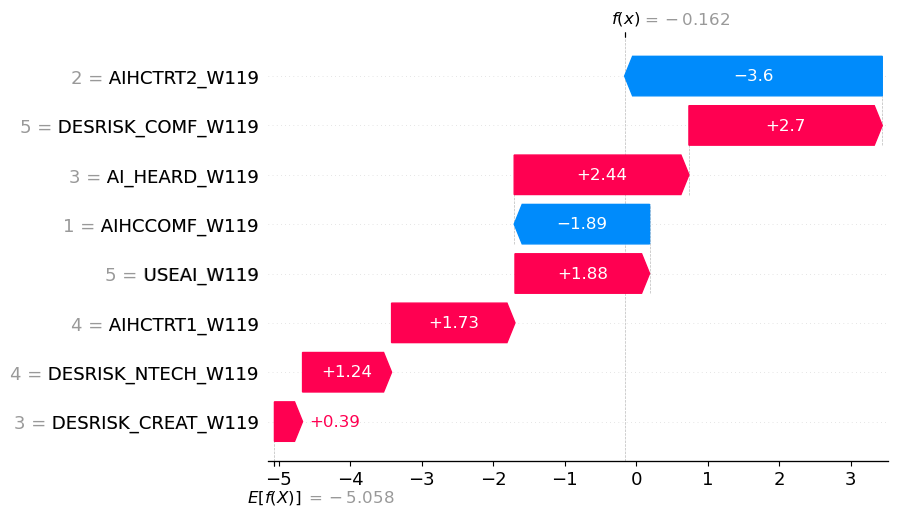

In [42]:
staff_input = {
    'AIHCTRT1_W119': 4,  # Trust in AI for Diagnosis
    'AIHCTRT2_W119': 2,  # Trust in AI for Treatment
    'USEAI_W119': 5,     # Frequency of AI Usage
    'AI_HEARD_W119': 3,  # Heard of AI
    'DESRISK_NTECH_W119': 4,  # AI reduces technical risks
    'DESRISK_COMF_W119': 5,   # Comfort using AI
    'DESRISK_CREAT_W119': 3,  # AI helps with creativity
    'AIHCCOMF_W119': 1        # Comfort with AI in healthcare
} 

def predict_and_explain_manual(input_dict):
    new_X = pd.DataFrame([input_dict])
    
    prob = model_small.predict_proba(new_X)[0][1]
    print(f"\n🔍 Predicted AI acceptance probability: {prob:.2f}")
    
    shap_values = explainer(new_X)
    shap.plots.waterfall(shap_values[0])

predict_and_explain_manual(staff_input)


# 5-Fold Cross-Validation Results (Using Top Features)

In [46]:

model = GradientBoostingClassifier(n_estimators=200, random_state=42)

X_top = X[top_features]


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])

scores = cross_validate(
    pipe, X_top, y,
    cv=cv,
    scoring=['accuracy', 'roc_auc'],
    n_jobs=-1,
    return_train_score=False
)

print("5-Fold Cross-Validation Results (Using Top Features):")
print(f"Mean Accuracy: {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
print(f"Mean ROC AUC: {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")

5-Fold Cross-Validation Results (Using Top Features):
Mean Accuracy: 0.9844 ± 0.0012
Mean ROC AUC: 0.9975 ± 0.0008
